# K-Means Clustering
K-Means is a centroid-based unsupervised learning algorithm. It works by partitioning n observations into k clusters, where each observation belongs to the cluster with the nearest mean (centroid). In this project, I am using it to identify natural groupings within a mall’s customer base to inform marketing strategies.

## Feature Selection and Scaling
For this analysis, I have selected Annual Income and Spending Score.

Annual Income: the customer's financial capacity.

Spending Score: metric (1-100) assigned by the mall based on purchase frequency and behavior.

 These features have different scales (income is in the thousands, while score is 1-100), so I applied StandardScaler. This ensures that the distance-based calculations of K-Means aren't biased toward the feature with larger raw numbers.

## Determining the Optimal Clusters: The Elbow Method
A critical step in K-Means is choosing the correct value for k (the number of clusters). I used the Within-Cluster Sum of Squares (WCSS) metric. WCSS measures how compact our clusters are; as k increases, WCSS naturally drops.

 "Elbow Point" is the moment where the rate of decrease shifts significantly. For this dataset, the elbow appears at k=5, suggesting that adding a 6th cluster provides diminishing returns in terms of data organization.

## Visualizing and Interpreting the Results
After training the model with k=5, we can visualize the five distinct customer segments:

Standard (Middle): Average income and average spending.

Target (High Income, High Spending): The "ideal" customer for high-end promotions.

Careful (High Income, Low Spending): Wealthy but frugal; may require better incentives to spend.

Sensible (Low Income, Low Spending): Budget conscious customers.

Spendthrift (Low Income, High Spending): High engagement despite lower income levels.

## Model Evaluation: Silhouette Score
To confirm the Elbow Method results, I calculated the Silhouette Score. This measures how similar an object is to its own cluster compared to other clusters. A higher score closer to 1 indicates that the clusters are well-separated and cohesive.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set theme
sns.set_theme()

# Load the Mall Customers dataset
df = pd.read_csv("Mall_Customers.csv")

# Renaming columns for easier access if necessary
df.columns = ["CustomerID", "Gender", "Age", "AnnualIncome", "SpendingScore"]

# Selecting Annual Income and Spending Score for clustering
X = df[['AnnualIncome', 'SpendingScore']].values

# Standardizing the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Data Sample:")
print(X_scaled[:5])

Scaled Data Sample:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


We use head() and describe() to understand the distribution of our customers.

In [3]:
# View first few rows
print(df.head())

# View statistical summary
print(df.describe())

   CustomerID  Gender  Age  AnnualIncome  SpendingScore
0           1    Male   19            15             39
1           2    Male   21            15             81
2           3  Female   20            16              6
3           4  Female   23            16             77
4           5  Female   31            17             40
       CustomerID         Age  AnnualIncome  SpendingScore
count  200.000000  200.000000    200.000000     200.000000
mean   100.500000   38.850000     60.560000      50.200000
std     57.879185   13.969007     26.264721      25.823522
min      1.000000   18.000000     15.000000       1.000000
25%     50.750000   28.750000     41.500000      34.750000
50%    100.500000   36.000000     61.500000      50.000000
75%    150.250000   49.000000     78.000000      73.000000
max    200.000000   70.000000    137.000000      99.000000


For my project, we will look at how Spending Score varies across different Age groups or Genders to see if there's an initial pattern.

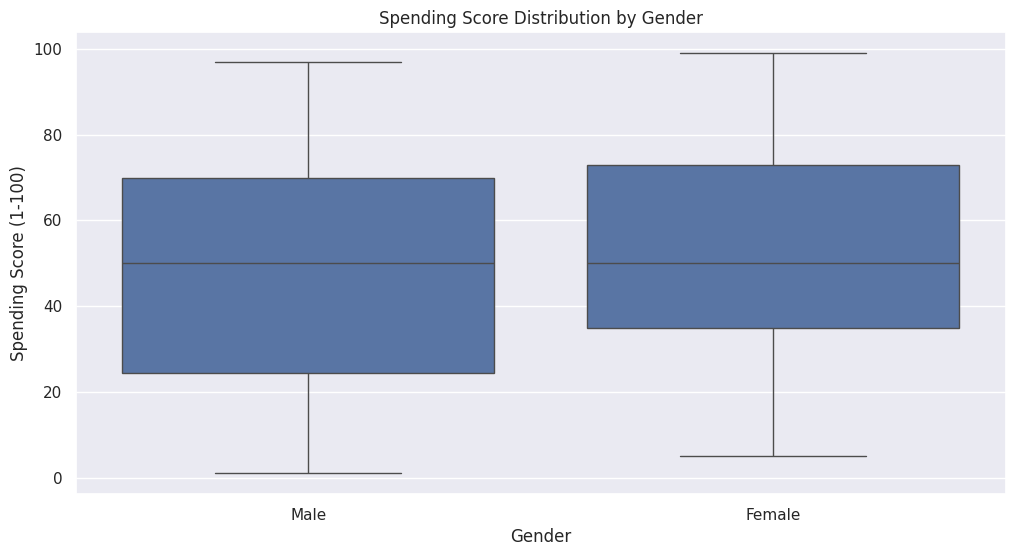

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="Gender", y="SpendingScore", data=df)
plt.title("Spending Score Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Spending Score (1-100)")
plt.show()

Calculate the WCSS to find the "elbow," which tells us the optimal number of clusters.

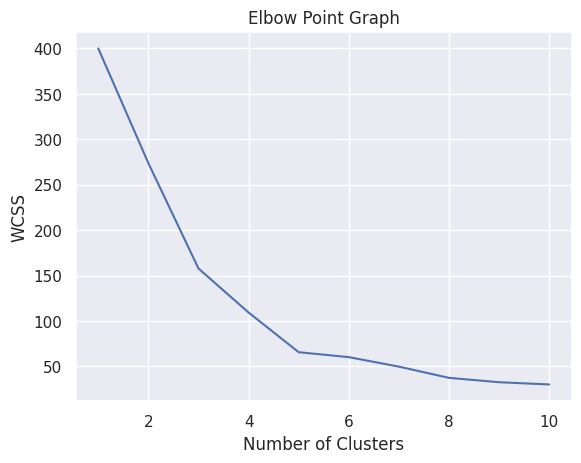

In [5]:
wcss = []
for num in range(1, 11):
    kmeans = KMeans(n_clusters=num, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Point Graph')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

Training the model: apply the KMeans algorithm using the optimal number of clusters found above.

In [6]:
# Based on the elbow, we choose 5 clusters
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)
Y = kmeans.fit_predict(X_scaled)

print("Cluster labels for first 10 points:")
print(Y[:10])

Cluster labels for first 10 points:
[3 4 3 4 3 4 3 4 3 4]


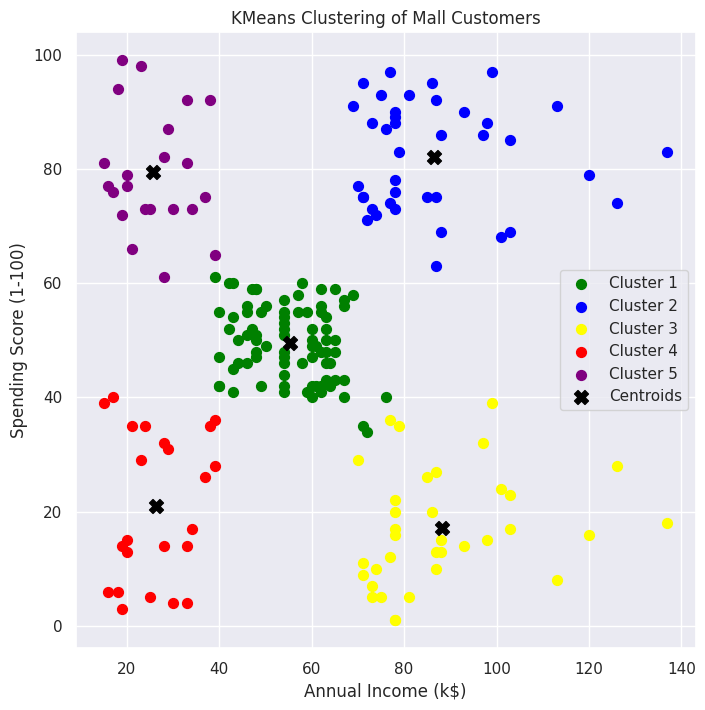

In [7]:
plt.figure(figsize=(8, 8))
# Plotting the 5 clusters
plt.scatter(X[Y==0, 0], X[Y==0, 1], s=50, c='green', label='Cluster 1')
plt.scatter(X[Y==1, 0], X[Y==1, 1], s=50, c='blue', label='Cluster 2')
plt.scatter(X[Y==2, 0], X[Y==2, 1], s=50, c='yellow', label='Cluster 3')
plt.scatter(X[Y==3, 0], X[Y==3, 1], s=50, c='red', label='Cluster 4')
plt.scatter(X[Y==4, 0], X[Y==4, 1], s=50, c='purple', label='Cluster 5')

# Plotting centroids (inverse transformed to show raw values)
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], s=100, c='black', marker='X', label='Centroids')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("KMeans Clustering of Mall Customers")
plt.legend()
plt.show()

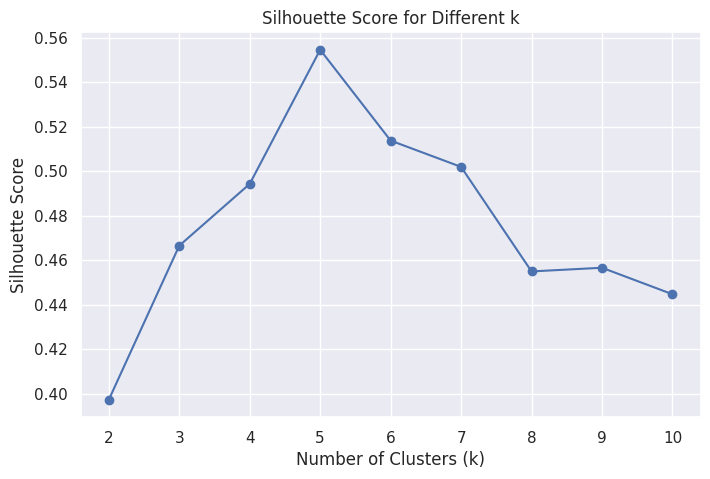

In [8]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Score for Different k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()